# **Parte IV: Análisis Exploratorio de Datos (EDA) y Visualización**

# **Cargar los Datos**

In [42]:
import pandas as pd
import requests

# Nos permite verificar que los datos se han cargado correctamente
# obtener una vista previa de su estructura y contenido inicial.

# Obtener datos
# Cargar datos desde un archivo CSV
df = pd.read_csv('/content/drive/MyDrive/retail_sales_dataset.csv')

# **Exploración Inicial de los Datos**

In [44]:
# Carga de datos correctamente
# Mostrar primeras 10 filas
print("nprimeras 10 filas del DataFrame:")
print(df.head(10))
# Mostrar las ultimas 5 filas
print("nultimas 5 filas del DataFrame:")
print(df.tail(5))
# Mostrar la información del DataFrame
print("\nInformación del DataFrame:")
print(df.info())
# Mostrar la información estadistica del DataFrame
print("\nEstadísticas descriptivas del DataFrame:")
print(df.describe())
# Mostrar valores nulos del DataFrame
print("\nConteo de valores nulos por columna en el DataFrame:")
print(df.isnull().sum())
# Mostrar conteo de filas duplicadas del DataFrame
print("\nConteo de filas duplicadas en el DataFrame:")
print(df.duplicated().sum())

nprimeras 10 filas del DataFrame:
   Transaction ID        Date Customer ID  Gender  Age Product Category  \
0               1  2023-11-24     CUST001    Male   34           Beauty   
1               2  2023-02-27     CUST002  Female   26         Clothing   
2               3  2023-01-13     CUST003    Male   50      Electronics   
3               4  2023-05-21     CUST004    Male   37         Clothing   
4               5  2023-05-06     CUST005    Male   30           Beauty   
5               6  2023-04-25     CUST006  Female   45           Beauty   
6               7  2023-03-13     CUST007    Male   46         Clothing   
7               8  2023-02-22     CUST008    Male   30      Electronics   
8               9  2023-12-13     CUST009    Male   63      Electronics   
9              10  2023-10-07     CUST010  Female   52         Clothing   

   Quantity  Price per Unit  Total Amount  
0         3              50           150  
1         2             500          1000  
2       

# **Inspección de los Datos**


In [7]:
# Para iniciar la obtencion de datos se utiliza dtypes
# Paso esencial en la preparación de datos
print("nTipos de datos de las columnas:")
print(df.dtypes)

nTipos de datos de las columnas:
Transaction ID       int64
Date                object
Customer ID         object
Gender              object
Age                  int64
Product Category    object
Quantity             int64
Price per Unit       int64
Total Amount         int64
dtype: object


In [26]:
# Convertir la columna 'Date' a tipo datetime
df['Date'] = pd.to_datetime(df['Date'])

print("\nTipos de datos después de convertir 'Date':")
print(df.dtypes)


Tipos de datos después de convertir 'Date':
Transaction ID               int64
Date                datetime64[ns]
Customer ID                 object
Gender                      object
Age                          int64
Product Category            object
Quantity                     int64
Price per Unit               int64
Total Amount                 int64
dtype: object


In [45]:
# Obtener el conteo de valores unicos de la columna "Product Category"
# Util para identificar las categorías más frecuentes

print("nConteo de valores únicos en la columna 'Product Category':")
print(df['Product Category'].value_counts())


nConteo de valores únicos en la columna 'Product Category':
Product Category
Clothing       351
Electronics    342
Beauty         307
Name: count, dtype: int64


# **Filtrado de Datos**

In [50]:
# Filas donde Total Amount sean mayores a 50.
df['Total Amount'] = df['Total Amount'].astype(float)
venta_mayor_50 = df[df['Total Amount'] > 50]

# Calcular el promedio de ventas por categoría de producto
average_sales_by_category = df.groupby('Product Category')['Total Amount'].mean().reset_index()

print("\nPromedio de ventas por Categoría de Producto:")
print(average_sales_by_category)



Promedio de ventas por Categoría de Producto:
  Product Category  Total Amount
0           Beauty    467.475570
1         Clothing    443.247863
2      Electronics    458.786550


In [51]:
# Mostrar las filas donde el 'Total Amount' es mayor a 50
print("\nFilas donde el 'Total Amount' es mayor a 50:")
display(venta_mayor_50)


Filas donde el 'Total Amount' es mayor a 50:


,Transaction ID,Date,Customer ID,Gender,Age,Product Category,Quantity,Price per Unit,Total Amount
0,1,2023-11-24,CUST001,Male,34,Beauty,3,50,150.0
1,2,2023-02-27,CUST002,Female,26,Clothing,2,500,1000.0
3,4,2023-05-21,CUST004,Male,37,Clothing,1,500,500.0
4,5,2023-05-06,CUST005,Male,30,Beauty,2,50,100.0
7,8,2023-02-22,CUST008,Male,30,Electronics,4,25,100.0
...,...,...,...,...,...,...,...,...,...
993,994,2023-12-18,CUST994,Female,51,Beauty,2,500,1000.0
996,997,2023-11-17,CUST997,Male,52,Beauty,3,30,90.0
997,998,2023-10-29,CUST998,Female,23,Beauty,4,25,100.0
998,999,2023-12-05,CUST999,Female,36,Electronics,3,50,150.0


In [52]:
# Calcular el promedio de ventas por categoría de producto
average_sales_by_category = df.groupby('Product Category')['Total Amount'].mean().reset_index()

print("\nPromedio de ventas por Categoría de Producto:")
print(average_sales_by_category)


Promedio de ventas por Categoría de Producto:
  Product Category  Total Amount
0           Beauty    467.475570
1         Clothing    443.247863
2      Electronics    458.786550


In [10]:
# Para verificar el rango de valores en 'Price per Unit':

print("nValor mínimo de 'Price per Unit':")
print(df['Price per Unit'].min())

# Se obtiene un precio minimo de 25.0
# evidencia que no es valido encontrar un precio menos a 0.5

nValor mínimo de 'Price per Unit':
25


In [53]:
# Se sacara el valor minimo de la columna "Price per Unit" para obtener el dato

df['Price per Unit'] = df['Price per Unit'].astype(float)
Precio_menor_100= df[df['Price per Unit'] < 100]
print("nFilas donde el precio es menor a 100:")
print(Precio_menor_100)

nFilas donde el precio es menor a 100:
     Transaction ID        Date Customer ID  Gender  Age Product Category  \
0                 1  2023-11-24     CUST001    Male   34           Beauty   
2                 3  2023-01-13     CUST003    Male   50      Electronics   
4                 5  2023-05-06     CUST005    Male   30           Beauty   
5                 6  2023-04-25     CUST006  Female   45           Beauty   
6                 7  2023-03-13     CUST007    Male   46         Clothing   
..              ...         ...         ...     ...  ...              ...   
995             996  2023-05-16     CUST996    Male   62         Clothing   
996             997  2023-11-17     CUST997    Male   52           Beauty   
997             998  2023-10-29     CUST998  Female   23           Beauty   
998             999  2023-12-05     CUST999  Female   36      Electronics   
999            1000  2023-04-12    CUST1000    Male   47      Electronics   

     Quantity  Price per Unit  Total

# **Slicing de Datos**

In [54]:
# Útil para concentrarse en un subconjunto específico de datos relevante para un análisis
ProductCategory_TotalAmount = df[['Product Category', 'Total Amount']]
print("nColumnas 'Product Category' y 'Total Amount':")
print(ProductCategory_TotalAmount)

nColumnas 'Product Category' y 'Total Amount':
    Product Category  Total Amount
0             Beauty         150.0
1           Clothing        1000.0
2        Electronics          30.0
3           Clothing         500.0
4             Beauty         100.0
..               ...           ...
995         Clothing          50.0
996           Beauty          90.0
997           Beauty         100.0
998      Electronics         150.0
999      Electronics         120.0

[1000 rows x 2 columns]


In [55]:
loc_result = df.loc[5:10, ['Product Category', 'Customer ID']]
print("nFilas 5 a 10 y columnas 'Product Category' y 'Customer ID' usando loc:")
print(loc_result)

nFilas 5 a 10 y columnas 'Product Category' y 'Customer ID' usando loc:
   Product Category Customer ID
5            Beauty     CUST006
6          Clothing     CUST007
7       Electronics     CUST008
8       Electronics     CUST009
9          Clothing     CUST010
10         Clothing     CUST011


In [56]:
# Selección posicional de datos.
iloc_result = df.iloc[0:5, 0:3]
print("nPrimeras 5 filas y primeras 3 columnas usando iloc:")
print(iloc_result)

nPrimeras 5 filas y primeras 3 columnas usando iloc:
   Transaction ID        Date Customer ID
0               1  2023-11-24     CUST001
1               2  2023-02-27     CUST002
2               3  2023-01-13     CUST003
3               4  2023-05-21     CUST004
4               5  2023-05-06     CUST005


# **Parte III: Transformación y Análisis Avanzado de Datos con Pandas**

**Transformación de Datos**

In [59]:
# Verificar valores únicos y sus conteos para la columna 'Gender'
print("\nConteo de valores únicos en la columna 'Gender':")
print(df['Gender'].value_counts())


Conteo de valores únicos en la columna 'Gender':
Gender
Female    510
Male      490
Name: count, dtype: int64


In [60]:
# Verificar valores únicos y sus conteos para la columna 'Product Category'
print("\nConteo de valores únicos en la columna 'Product Category':")
print(df['Product Category'].value_counts())


Conteo de valores únicos en la columna 'Product Category':
Product Category
Clothing       351
Electronics    342
Beauty         307
Name: count, dtype: int64


In [12]:
filtered_sliced = df[df['Total Amount'] > 50].loc[:, ['Product Category', 'Price per Unit']]
print(filtered_sliced)

    Product Category  Price per Unit
0             Beauty            50.0
1           Clothing           500.0
3           Clothing           500.0
4             Beauty            50.0
7        Electronics            25.0
..               ...             ...
993           Beauty           500.0
996           Beauty            30.0
997           Beauty            25.0
998      Electronics            50.0
999      Electronics            30.0

[783 rows x 2 columns]


In [13]:
filtered_sliced = df[df['Quantity'] > 2].loc[:, ['Product Category', 'Price per Unit']]
print(filtered_sliced)

    Product Category  Price per Unit
0             Beauty            50.0
7        Electronics            25.0
9           Clothing            50.0
11            Beauty            25.0
12       Electronics           500.0
..               ...             ...
992      Electronics            50.0
996           Beauty            30.0
997           Beauty            25.0
998      Electronics            50.0
999      Electronics            30.0

[504 rows x 2 columns]


In [14]:
# Normalizar la columna 'Total Amount'
max_value = df['Total Amount'].max()
min_value = df['Total Amount'].min()
df['Total_Amount_normalizado'] = df['Total Amount'].apply(lambda x: (x - min_value) / (max_value - min_value))

# Imprimir las columnas relevantes para verificar el resultado (mostrar las primeras filas)
print(df[['Total Amount', 'Total_Amount_normalizado']].head())

# Normalizar la columna 'Quantity'
max_value = df['Quantity'].max()
min_value = df['Quantity'].min()
df['Quantity_normalizado'] = df['Quantity'].apply(lambda x: (x - min_value) / (max_value - min_value))

# Imprimir las columnas relevantes para verificar el resultado (mostrar las primeras filas)
print(df[['Quantity', 'Quantity_normalizado']].head())

   Total Amount  Total_Amount_normalizado
0         150.0                  0.063291
1        1000.0                  0.493671
2          30.0                  0.002532
3         500.0                  0.240506
4         100.0                  0.037975
   Quantity  Quantity_normalizado
0         3              0.666667
1         2              0.333333
2         1              0.000000
3         1              0.000000
4         2              0.333333


**Clasificación de datos**





In [61]:
# Clasificación de 'Total Amount' en categorías:

def Clasificación_de_ventas(score):
    if score <= 100:
        return 'Baja'
    elif score <= 200:
        return 'Media'
    else:
        return 'Alta'

df['Clasificacion_de_ventas'] = df['Total Amount'].apply(Clasificación_de_ventas)

print("Primeras filas con la nueva clasificación de satisfacción:")
print(df[['Total Amount', 'Clasificacion_de_ventas']].head())

Primeras filas con la nueva clasificación de satisfacción:
   Total Amount Clasificacion_de_ventas
0         150.0                   Media
1        1000.0                    Alta
2          30.0                    Baja
3         500.0                    Alta
4         100.0                    Baja


# **Agrupación y Agregación**

**Agrupación por múltiples columnas:** Realiza agrupaciones por categorías como producto y tienda, producto y mes, etc.

In [16]:
grouped = df.groupby(['Product Category', 'Gender'])

# Suma y promedio de Cantidad por Product Category y Gender
Cantidad_por_Product_Category_por_Gender = grouped['Quantity'].agg(['sum', 'mean'])
print(Cantidad_por_Product_Category_por_Gender)

                         sum      mean
Product Category Gender               
Beauty           Female  418  2.518072
                 Male    353  2.503546
Clothing         Female  441  2.534483
                 Male    453  2.559322
Electronics      Female  439  2.582353
                 Male    410  2.383721


In [62]:
grouped_multi = df.groupby(['Product Category','Gender'])

# Suma de Total Amount por Product Category y Gender
total_amount_por_product_category_y_gender = grouped_multi['Total Amount'].sum()
print(total_amount_por_product_category_y_gender)

# Promedio de Total Amount por Product Category y Gender
promedio_total_amount_por_product_category_y_gender = grouped_multi['Total Amount'].mean()
print(promedio_total_amount_por_product_category_y_gender)

# Aplicar múltiples funciones de agregación a 'Total Amount' agrupadas por 'Product Category'
agg_result = df.groupby('Product Category')['Total Amount'].agg(['sum', 'mean', 'count'])
print(agg_result)
# Calcular el rango (max - min) de Total Amount por Product Category
rango_total_amount_por_product_category = df.groupby('Product Category')['Total Amount'].apply(lambda x: x.max() - x.min())

Product Category  Gender
Beauty            Female    74830.0
                  Male      68685.0
Clothing          Female    81275.0
                  Male      74305.0
Electronics       Female    76735.0
                  Male      80170.0
Name: Total Amount, dtype: float64
Product Category  Gender
Beauty            Female    450.783133
                  Male      487.127660
Clothing          Female    467.097701
                  Male      419.802260
Electronics       Female    451.382353
                  Male      466.104651
Name: Total Amount, dtype: float64
                       sum        mean  count
Product Category                             
Beauty            143515.0  467.475570    307
Clothing          155580.0  443.247863    351
Electronics       156905.0  458.786550    342


# **Análisis Personalizado con apply**

In [63]:
# Nos ayuda para análisis más avanzados
# Calcular el ingreso tomando la Cantidad y Precio_Unitario
df['Ingreso'] = df.apply(lambda row: row['Quantity'] * row['Price per Unit'], axis=1)

# Calcular el ingreso tomando la Cantidad y Precio_Unitario
df['Ingreso'] = df['Total Amount'].apply(lambda x: 'Alta' if x > 200 else 'Baja')

# Clasificar la Cantidad por rango de compra
df['Clasificación'] = df['Quantity'].apply(lambda x: 'Alta' if x > 2 else 'Baja')

# Normalizar la columna 'Cantidad'
max_Cantidad = df['Quantity'].max()
min_Cantidad = df['Quantity'].min()
df['Quantity_normalizado'] = df['Quantity'].apply(lambda x: (x - min_Cantidad) / (max_Cantidad - min_Cantidad))

# Mostrar las columnas 'Ingreso' y 'Cantidad_normalizado' del DataFrame resultante
print(df[['Ingreso', 'Clasificación','Quantity_normalizado']])

    Ingreso Clasificación  Quantity_normalizado
0      Baja          Alta              0.666667
1      Alta          Baja              0.333333
2      Baja          Baja              0.000000
3      Alta          Baja              0.000000
4      Baja          Baja              0.333333
..      ...           ...                   ...
995    Baja          Baja              0.000000
996    Baja          Alta              0.666667
997    Baja          Alta              1.000000
998    Baja          Alta              0.666667
999    Baja          Alta              1.000000

[1000 rows x 3 columns]


**Ejemplo de uso avanzado:** Calcula la desviación de cada venta respecto a la media de su grupo.

In [64]:
import numpy as np

# Calcular la desviación absoluta media para 'Total Amount'
mean_total_amount = df['Total Amount'].mean()
df['MAD_Total_Amount'] = df['Total Amount'].apply(lambda x: np.abs(x - mean_total_amount))
print(df[['Total Amount', 'MAD_Total_Amount']].head())

   Total Amount  MAD_Total_Amount
0         150.0             306.0
1        1000.0             544.0
2          30.0             426.0
3         500.0              44.0
4         100.0             356.0


In [65]:
# Calcular la media de 'Total Amount' para cada 'Product Category'
df['Mean_Total_Amount_by_Category'] = df.groupby('Product Category')['Total Amount'].transform('mean')

# Calcular la desviación de cada venta respecto a la media de su categoría
df['Deviation_from_Category_Mean'] = df['Total Amount'] - df['Mean_Total_Amount_by_Category']

# Mostrar las columnas relevantes para verificar el resultado (mostrar las primeras filas)
print(df[['Product Category', 'Total Amount', 'Mean_Total_Amount_by_Category', 'Deviation_from_Category_Mean']].head())

  Product Category  Total Amount  Mean_Total_Amount_by_Category  \
0           Beauty         150.0                     467.475570   
1         Clothing        1000.0                     443.247863   
2      Electronics          30.0                     458.786550   
3         Clothing         500.0                     443.247863   
4           Beauty         100.0                     467.475570   

   Deviation_from_Category_Mean  
0                   -317.475570  
1                    556.752137  
2                   -428.786550  
3                     56.752137  
4                   -367.475570  


# **Parte IV: Análisis Exploratorio de Datos (EDA) y Visualización**

**Ventas por Categoría de Producto**

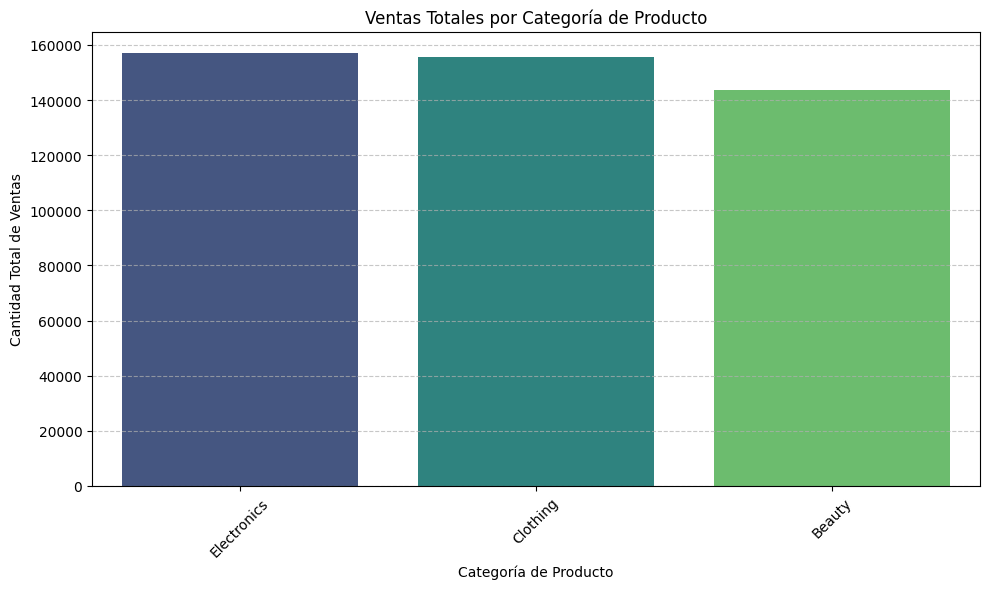

In [66]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Ventas por Categoría de Producto
sales_by_category = df.groupby('Product Category')['Total Amount'].sum().sort_values(ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(x=sales_by_category.index, y=sales_by_category.values, palette='viridis', hue=sales_by_category.index, legend=False)
plt.title('Ventas Totales por Categoría de Producto')
plt.xlabel('Categoría de Producto')
plt.ylabel('Cantidad Total de Ventas')
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()


El gráfico de barras nos muestra que las categorías de Clothing y Electronics tienen volúmenes de ventas totales similares. Esto nos sugiere que son las columnas principales del negocio, donde se concentra la mayor parte del flujo de ingresos.La categoría de Beauty presenta un volumen de ventas inferior.

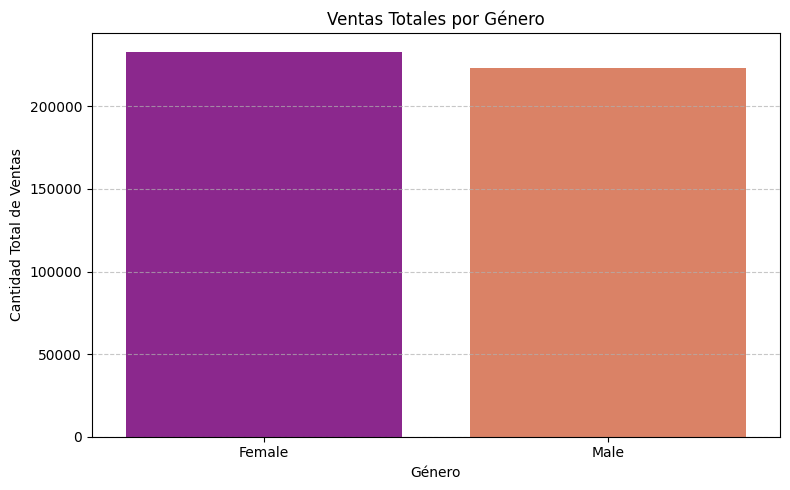

In [30]:
# 2. Ventas por Género
sales_by_gender = df.groupby('Gender')['Total Amount'].sum().sort_values(ascending=False)

plt.figure(figsize=(8, 5))
sns.barplot(x=sales_by_gender.index, y=sales_by_gender.values, palette='plasma', hue=sales_by_gender.index, legend=False)
plt.title('Ventas Totales por Género')
plt.xlabel('Género')
plt.ylabel('Cantidad Total de Ventas')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

El gráfico de barras muestra que las mujeres (Female) contribuyen con un monto total de ventas ligeramente superior en comparación con los hombres (Male).

# **Análisis Descriptivo y Visualización**

**1. Estadísticas Descriptivas**: Calcula estadísticas descriptivas básicas para comprender mejor las características de los datos.

In [31]:
# Calcular estadísticas descriptivas básicas para las columnas numéricas
print("\nEstadísticas descriptivas de las variables numéricas:")
display(df.describe())


Estadísticas descriptivas de las variables numéricas:


,Transaction ID,Date,Age,Quantity,Price per Unit,Total Amount
count,1000.000000,1000,1000.00000,1000.000000,1000.000000,1000.000000
mean,500.500000,2023-07-03 00:25:55.200000256,41.39200,2.514000,179.890000,456.000000
min,1.000000,2023-01-01 00:00:00,18.00000,1.000000,25.000000,25.000000
25%,250.750000,2023-04-08 00:00:00,29.00000,1.000000,30.000000,60.000000
50%,500.500000,2023-06-29 12:00:00,42.00000,3.000000,50.000000,135.000000
75%,750.250000,2023-10-04 00:00:00,53.00000,4.000000,300.000000,900.000000
max,1000.000000,2024-01-01 00:00:00,64.00000,4.000000,500.000000,2000.000000
std,288.819436,NaN,13.68143,1.132734,189.681356,559.997632


**2. Histogramas y boxplots para visualizar la distribución de las variables numéricas clave.**

**Histograma**

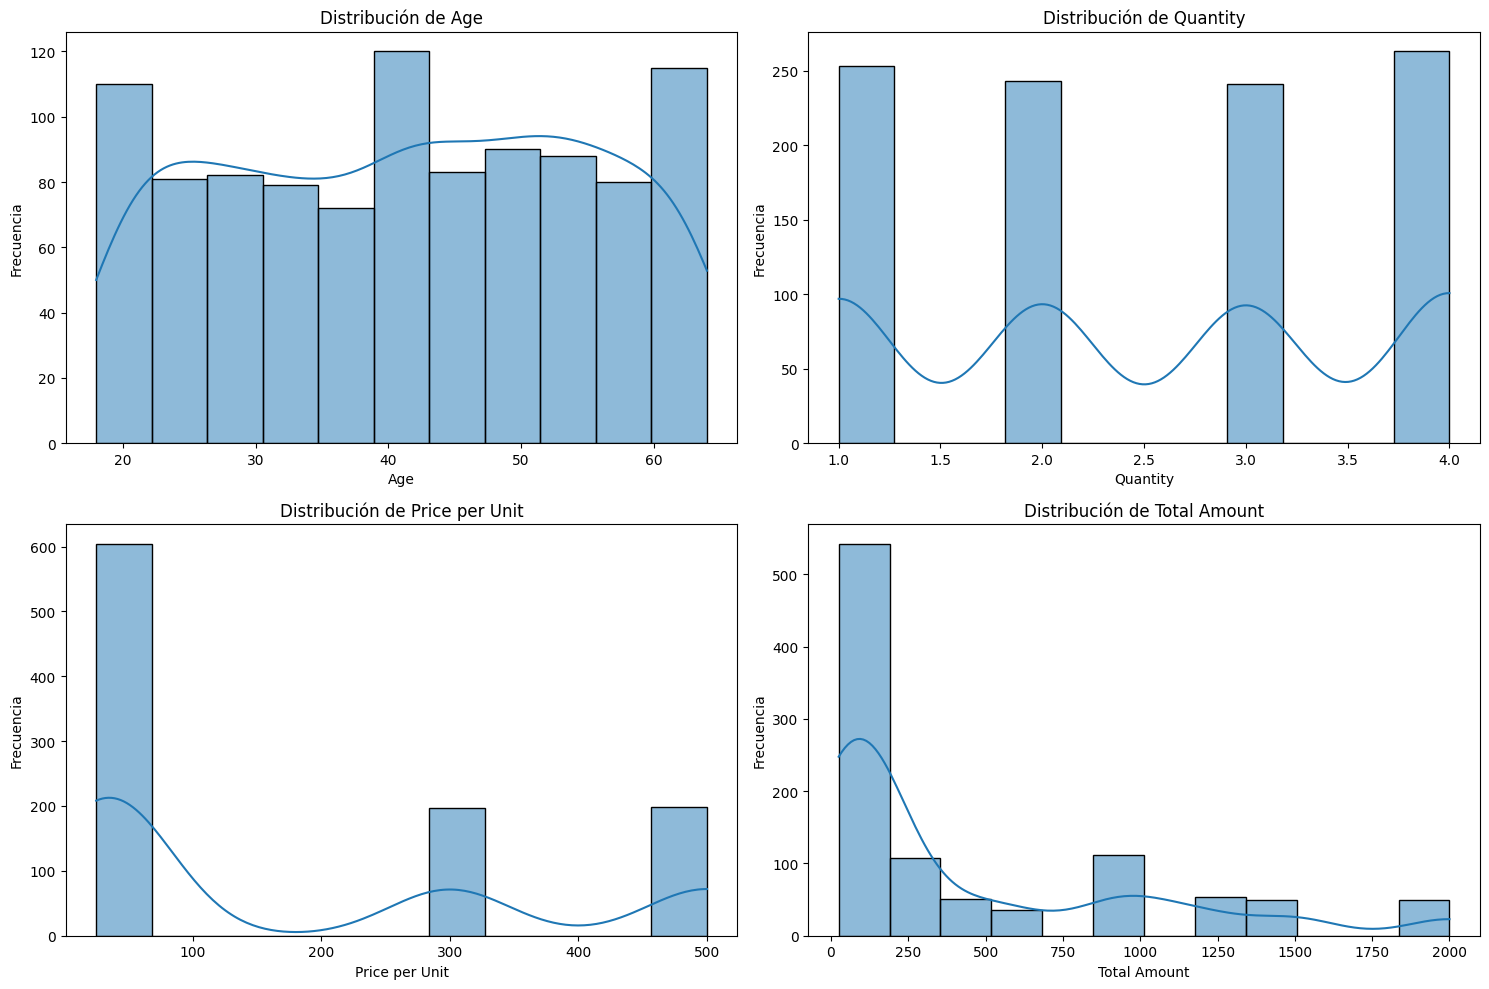

In [32]:
numerical_cols = ['Age', 'Quantity', 'Price per Unit', 'Total Amount']

plt.figure(figsize=(15, 10))
for i, col in enumerate(numerical_cols):
    plt.subplot(2, 2, i + 1) # 2 filas, 2 columnas
    sns.histplot(df[col], kde=True)
    plt.title(f'Distribución de {col}')
    plt.xlabel(col)
    plt.ylabel('Frecuencia')
plt.tight_layout()
plt.show()

Los histogramas nos ofrecen una visión analítica clave sobre la estructura y el comportamiento de las variables numéricas de nuestro dataset:

*   Distribución de 'Age' (Edad): Se puede observando que las edades de nuestros clientes abarcan un rango amplio (de 18 a 64 años), con una media alrededor de 41 años. La franja de edad entre 30-50 años representa mayor predominio.

*   Distribución de 'Quantity' (Cantidad): Dada la escala de nuestro dataset (cantidades de 1 a 4), el histograma muestra una mayor frecuencia de transacciones con 1 o 2 unidades, es decir de bajo volumen.

*   Distribución de 'Price per Unit' (Precio por Unidad):El histograma revela los rangos de precios más comunes de los productos vendidos (entre 25 y 500 unidades monetarias). Se observan picos en precios bajos (como 25 o 50) y también en precios más altos (como 300 o 500). Nos indica la existencia de productos de alta rotación en diferentes rangos de precio.

*   Distribución de 'Total Amount' (Monto Total): El histograma para el 'Monto Total' en nuestro dataset, nos muestra que la mayoría de nuestras ventas son de bajo o medio valor. Solo un pequeño número de transacciones de alto valor contribuyen significativamente a los ingresos totales.

**Boxplot**

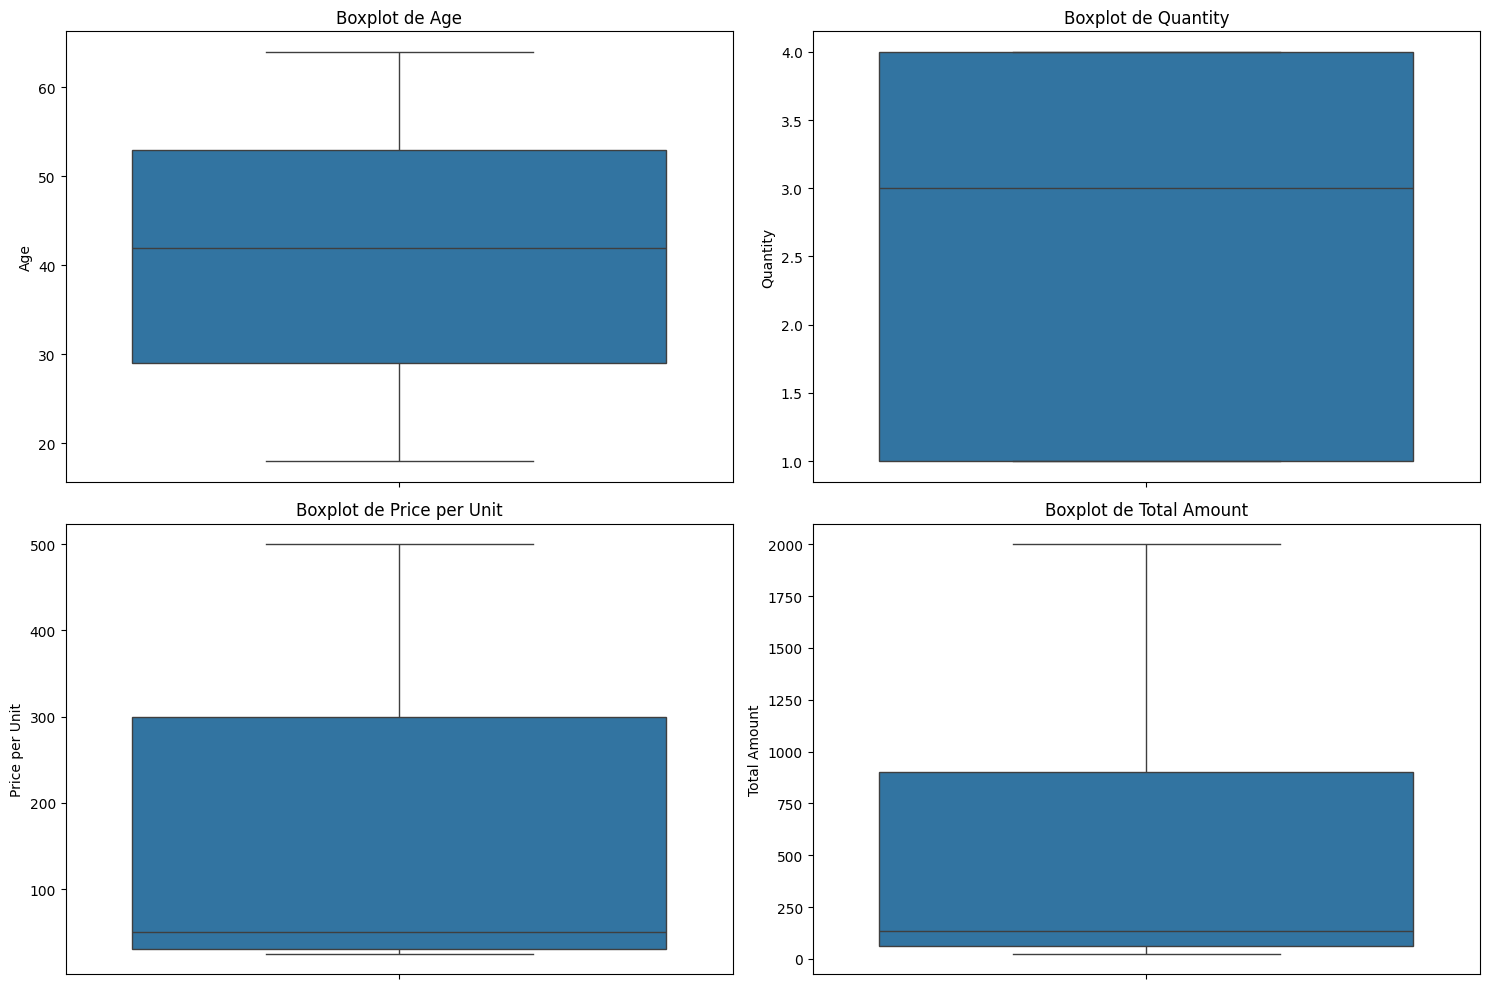

In [33]:
plt.figure(figsize=(15, 10))
for i, col in enumerate(numerical_cols):
    plt.subplot(2, 2, i + 1)
    sns.boxplot(y=df[col])
    plt.title(f'Boxplot de {col}')
    plt.ylabel(col)
plt.tight_layout()
plt.show()

*   Boxplot de 'Age' (Edad): Nos proporciona una vista rápida de la mediana de edad de nuestros clientes (aproximadamente 41 años) y la variabilidad en torno a ella (el 50% central de los clientes se encuentra entre 29 y 53 años).
*   Boxplot de 'Quantity' (Cantidad):Dada la limitada variación de 'Quantity' (1 a 4 unidades), se ilustrarála mediana y la dispersión, con los bigotes mostrando los límites de las cantidades más comunes.

*   Boxplot de 'Price per Unit' (Precio por Unidad):Clave para entender la dispersión de los precios de nuestros productos. Con un rango que va de 25 a 500, podemos ver dónde se concentra la mayoría de los precios y si existen

*   Boxplot de 'Total Amount' (Monto Total):Esto es crucial para la gestión de ingresos. Nos muestra el rango del 50% de nuestras ventas (entre 60 y 900), con una mediana en 135 unidades.

**3. Gráficos de líneas - Tendencias de ventas a lo largo del tiempo.**

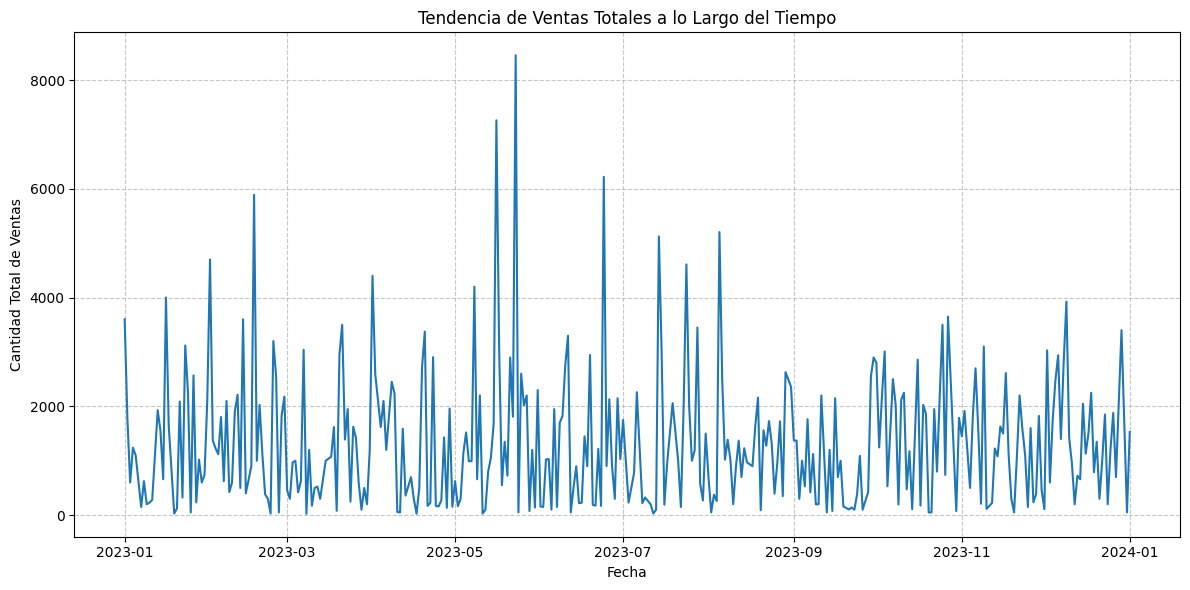

In [34]:
# Agrupar las ventas por fecha y calcular la suma total
daily_sales = df.groupby('Date')['Total Amount'].sum().reset_index()

plt.figure(figsize=(12, 6))
sns.lineplot(x='Date', y='Total Amount', data=daily_sales)
plt.title('Tendencia de Ventas Totales a lo Largo del Tiempo')
plt.xlabel('Fecha')
plt.ylabel('Cantidad Total de Ventas')
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

El gráfico, revelará patrones generales de ventas a lo largo del periodo, reflejando la mayor tendencia de ventas en el mes de mayo.

**4. Gráfico de dispersión – relación entre diferentes variables.**

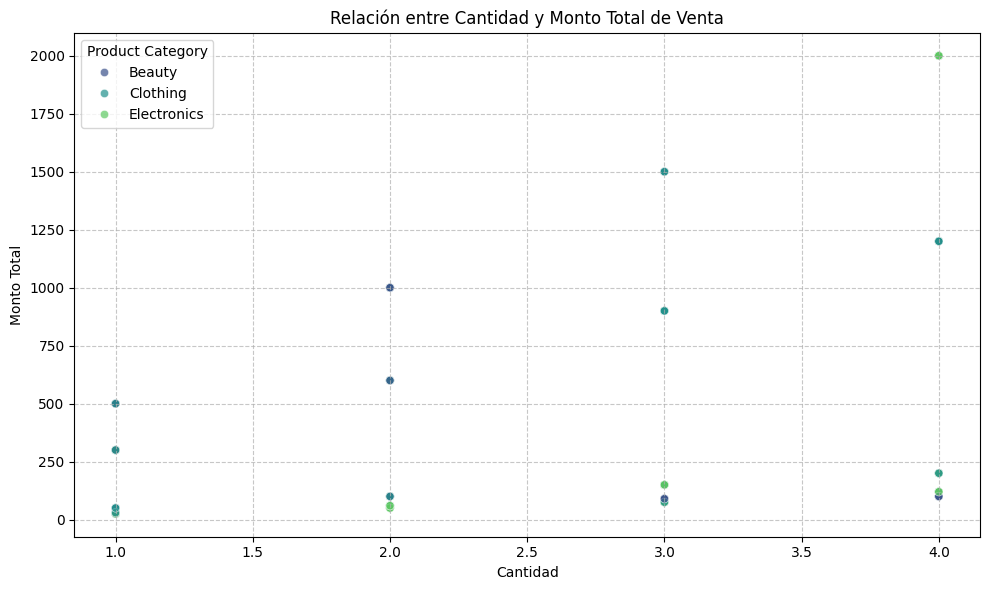

In [35]:
# Gráfico de dispersión entre Cantidad y Monto Total
plt.figure(figsize=(10, 6))
sns.scatterplot(x='Quantity', y='Total Amount', data=df, hue='Product Category', palette='viridis', alpha=0.7)
plt.title('Relación entre Cantidad y Monto Total de Venta')
plt.xlabel('Cantidad')
plt.ylabel('Monto Total')
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

La gráfica nos ayudará a visualizar cómo la cantidad de productos comprados se relaciona con el monto total de la venta para cada categoría.


**5. Combinación de histogramas y boxplots para visualizar la distribución de las ventas y detectar valores atípicos.**

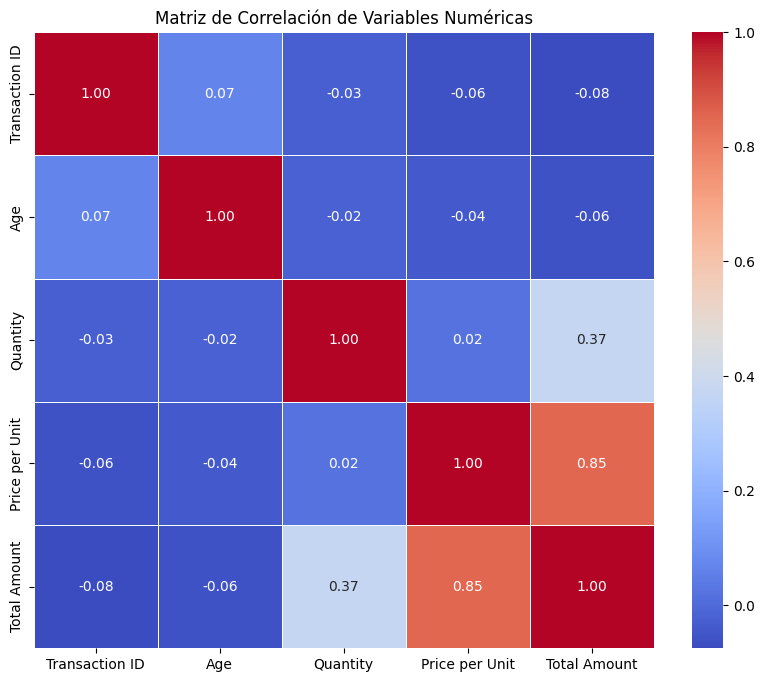

In [37]:
import matplotlib.pyplot as plt
import seaborn as sns

# Seleccionar solo las columnas numéricas para el cálculo de correlación
numerical_df = df.select_dtypes(include=['number'])

# Calcular la matriz de correlación
correlation_matrix = numerical_df.corr()

plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=.5)
plt.title('Matriz de Correlación de Variables Numéricas')
plt.show()

La grafica de correlacion, muestra una  correlaciones positivas entre 'Price per Unit' y 'Total Amount' (0.85), indicandonos que el precio unitario es un factor dominante en el monto total de la venta.
